# SVM Demand Prediction — Improved: Threshold-Based Area Selection

This notebook is the improved successor to `03.01_prediction_svm.ipynb`.
It addresses two structural weaknesses identified during exploration:

**Problem 1 — A single model across all 77 areas fails.**
Demand scales differ by up to 400× between areas. CA 8 (Near North Side) can have 1,916 trips
in a single 4-hour window; CA 18 (Montclare) typically has 1–2. A single regression model trained
on this mix is dominated by high-demand areas. The loss function penalises errors in CA 8 far more
than in CA 18, so the model learns CA 8's patterns and mostly ignores the rest.

**Problem 2 — Per-area models for sparse areas produce noise, not predictions.**
Areas with near-zero demand have almost no variance in their target values. Even a prediction error
of 1 trip can exceed the total target variance (SS_tot), producing a negative R². The 10 worst-performing
areas in `03.01` had MSE < 2 but R² below −1.3 — the model was less useful than always predicting the mean.

**Solution — train per-area models only where there is sufficient demand signal.**
A threshold of median 4-hour demand > 10 trips is applied. Below this level there is no reliably
learnable temporal pattern. Two model tiers are trained and compared:
1. **LinearSVR baseline** — fast, interpretable, provides feature coefficient weights
2. **RBF SVR** — non-linear kernel, expected to outperform the baseline on rush-hour peaks


In [152]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.patches import Patch
from sklearn.svm import SVR, LinearSVR
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import contextily as ctx

TAXI_DATA_PATH       = "../data/chicago_taxi_2025_clean.parquet"
WEATHER_DATA_PATH    = "../data/chicago_weather_2025_hourly.csv"
POI_DATA_PATH        = "../data/poi_chicago.geojson"
COMMUNITY_AREAS_PATH = "../data/community_areas_chicago.geojson"


## 1. Data Loading & Feature Engineering

The pipeline below is identical to `03.01`: hourly aggregation, 4-hour resampling, cyclic time features,
weather join, and holiday/weekend flags. `weather_code` and `apparent_temperature` are dropped for the
same reasons documented in `03.01` (non-ordinal scale and high collinearity respectively).


In [153]:
taxi_data    = pd.read_parquet(TAXI_DATA_PATH)
weather_data = pd.read_csv(WEATHER_DATA_PATH)

# Hourly aggregation
taxi_data['trip_start_timestamp_rounded'] = (
    pd.to_datetime(taxi_data['trip_start_timestamp']).dt.floor('h')
)
taxi_data_feats = (
    taxi_data
    .groupby(['pickup_community_area', 'trip_start_timestamp_rounded'])
    .size()
    .reset_index(name='count')
    .rename(columns={'pickup_community_area': 'community_area',
                     'trip_start_timestamp_rounded': 'timestamp'})
)

# Weather join
weather_data['datetime'] = pd.to_datetime(weather_data['datetime'])
taxi_data_feats = taxi_data_feats.join(
    weather_data.set_index('datetime'), on='timestamp', how='left'
)

# Drop non-usable weather columns
taxi_data_feats.drop(
    columns=[c for c in ['weather_description', 'weather_code', 'apparent_temperature']
             if c in taxi_data_feats.columns],
    inplace=True
)


In [154]:
# 4-hour aggregation + feature engineering
df_all = taxi_data_feats.copy()
df_all['timestamp'] = pd.to_datetime(df_all['timestamp'])
df_all['timestamp_4h'] = df_all['timestamp'].dt.floor('4h')

df_all = df_all.groupby(['community_area', 'timestamp_4h']).agg({
    'count':          'sum',
    'temperature_2m': 'mean',
    'precipitation':  'mean',
    'snowfall':       'mean',
    'wind_speed_10m': 'mean',
    'cloud_cover':    'mean',
}).reset_index()

# Cyclic time features
df_all['hour']        = df_all['timestamp_4h'].dt.hour
df_all['day_of_week'] = df_all['timestamp_4h'].dt.dayofweek
df_all['month']       = df_all['timestamp_4h'].dt.month

df_all['hour_sin']        = np.sin(2 * np.pi * df_all['hour'] / 24)
df_all['hour_cos']        = np.cos(2 * np.pi * df_all['hour'] / 24)
df_all['day_of_week_sin'] = np.sin(2 * np.pi * df_all['day_of_week'] / 7)
df_all['day_of_week_cos'] = np.cos(2 * np.pi * df_all['day_of_week'] / 7)
df_all['month_sin']       = np.sin(2 * np.pi * df_all['month'] / 12)
df_all['month_cos']       = np.cos(2 * np.pi * df_all['month'] / 12)

# Binary flags
df_all['is_weekend'] = (df_all['timestamp_4h'].dt.dayofweek >= 5).astype(int)

us_holidays_2025 = pd.to_datetime([
    '2025-01-01', '2025-01-20', '2025-02-17', '2025-05-26',
    '2025-06-19', '2025-07-04', '2025-09-01', '2025-10-13',
    '2025-11-11', '2025-11-27', '2025-12-25'
])
df_all['is_holiday'] = df_all['timestamp_4h'].dt.date.isin(us_holidays_2025.date).astype(int)

df_all.drop(columns=['timestamp_4h', 'hour', 'day_of_week', 'month'], inplace=True)

print(f"Rows: {len(df_all)}, Areas: {df_all['community_area'].nunique()}")
df_all.head(3)


Rows: 137680, Areas: 77


,community_area,count,temperature_2m,precipitation,snowfall,wind_speed_10m,cloud_cover,hour_sin,hour_cos,day_of_week_sin,day_of_week_cos,month_sin,month_cos,is_weekend,is_holiday
0,1,15,0.575000,0.025,0.0175,9.050000,100.000000,0.000000,1.0,0.974928,-0.222521,0.5,0.866025,0,1
1,1,8,-0.400000,0.000,0.0000,10.300000,100.000000,0.866025,0.5,0.974928,-0.222521,0.5,0.866025,0,1
2,1,13,-1.266667,0.000,0.0000,13.533333,63.333333,0.866025,-0.5,0.974928,-0.222521,0.5,0.866025,0,1


## 2. Demand Heterogeneity Across Community Areas

Before any modelling, we need to understand how radically different taxi demand is
across Chicago's 77 community areas. The visualisations in this section motivate why
neither a single global model nor per-area models for all areas is appropriate.


In [155]:
# Per-area summary statistics
area_stats = (
    df_all.groupby('community_area')['count']
    .agg(median='median', mean='mean', max='max', std='std', n_rows='count')
    .reset_index()
    .sort_values('median', ascending=False)
)
area_stats[['median','mean','std']] = area_stats[['median','mean','std']].round(2)

print(f"Areas with median demand >= 10: {(area_stats['median'] >= 10).sum()}")
print(f"Areas with median demand <  10: {(area_stats['median'] < 10).sum()}")
print(f"\nHighest median: {area_stats['median'].max():.1f}  |  "
      f"Lowest median: {area_stats['median'].min():.1f}  |  "
      f"Ratio: {area_stats['median'].max() / max(area_stats['median'].min(), 0.01):.0f}×")


Areas with median demand >= 10: 21
Areas with median demand <  10: 56

Highest median: 595.0  |  Lowest median: 1.0  |  Ratio: 595×


### 2.1 Median Demand per Community Area

The bar chart below sorts all 77 areas by median 4-hour demand. The dashed line marks
the threshold of 10 trips per window.

Two distinct clusters are visible:
- A group of **high-demand areas** (blue) where temporal patterns are strong enough to model
- A long tail of **near-zero areas** (red) where demand is essentially random noise

This structure is the fundamental reason a single global model fails.


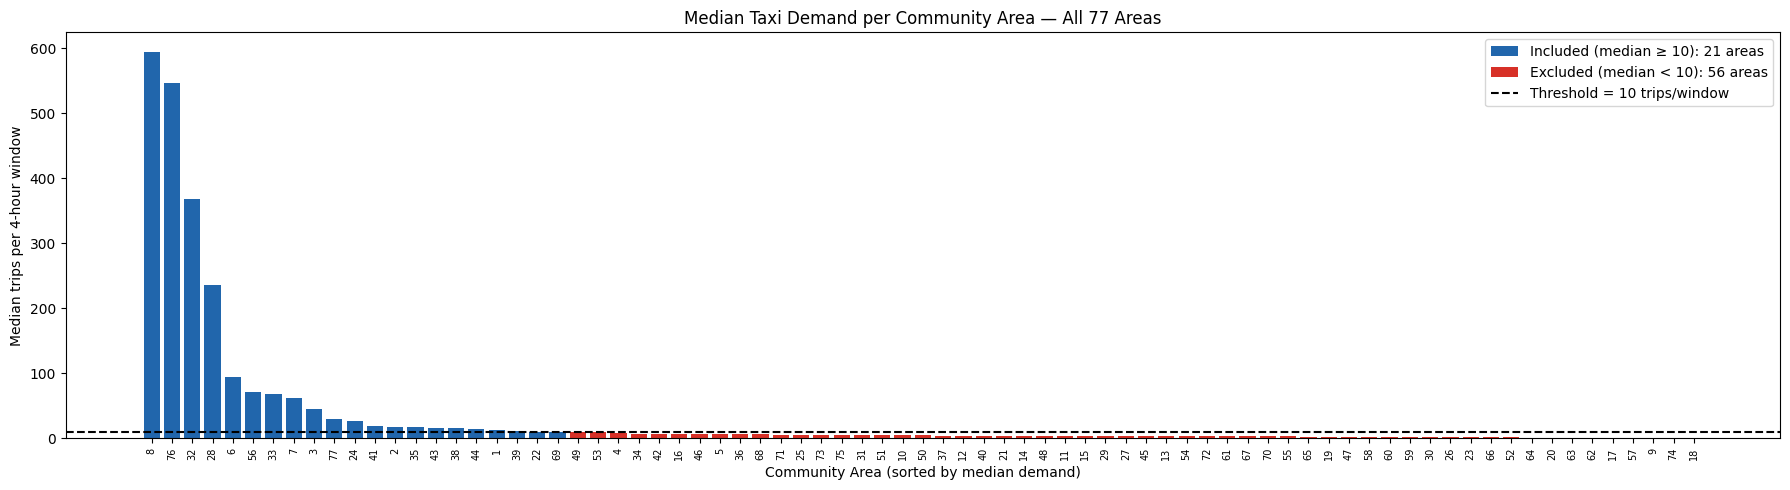

In [156]:
DEMAND_THRESHOLD = 10

sorted_stats = area_stats.sort_values('median', ascending=False)
colors       = ['#2166ac' if m >= DEMAND_THRESHOLD else '#d73027' for m in sorted_stats['median']]

fig, ax = plt.subplots(figsize=(18, 5))
ax.bar(range(len(sorted_stats)), sorted_stats['median'], color=colors, width=0.8)
ax.axhline(y=DEMAND_THRESHOLD, color='black', linestyle='--', linewidth=1.5)
ax.set_xticks(range(len(sorted_stats)))
ax.set_xticklabels(sorted_stats['community_area'].astype(str), rotation=90, fontsize=7)
ax.set_xlabel('Community Area (sorted by median demand)')
ax.set_ylabel('Median trips per 4-hour window')
ax.set_title('Median Taxi Demand per Community Area — All 77 Areas')

n_included = (sorted_stats['median'] >= DEMAND_THRESHOLD).sum()
n_excluded = (sorted_stats['median'] <  DEMAND_THRESHOLD).sum()
legend_elements = [
    Patch(facecolor='#2166ac', label=f'Included (median ≥ {DEMAND_THRESHOLD}): {n_included} areas'),
    Patch(facecolor='#d73027', label=f'Excluded (median < {DEMAND_THRESHOLD}): {n_excluded} areas'),
    plt.Line2D([0], [0], color='black', linestyle='--', label=f'Threshold = {DEMAND_THRESHOLD} trips/window')
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()


### Why a single model for all 77 areas fails

The chart above shows demand differs by up to **400×** between the highest and lowest areas.
When a single regression model (SVR or otherwise) is trained on all areas simultaneously:

- The **loss function is dominated by high-demand areas** — a prediction error of ±100 trips
  in CA 8 contributes ~10,000 to the sum of squared errors; a ±1 error in CA 18 contributes only 1.
- The optimiser learns the patterns of CA 8, CA 32, and CA 76 very well and effectively
  **ignores the structure of the remaining 70+ areas**.
- The reported overall R² looks good (~0.55–0.92) but hides that sparse areas are predicted
  with negative R² — worse than just predicting the mean.

This is equivalent to fitting one regression model through data from 77 different populations
with completely different scales — statistically incorrect.


### 2.2 Demand Distribution for Representative Areas

The histograms below compare the trip-count distributions for four areas across the demand spectrum.
They make clear why per-area models cannot work for sparse areas: there is simply no variation to model.


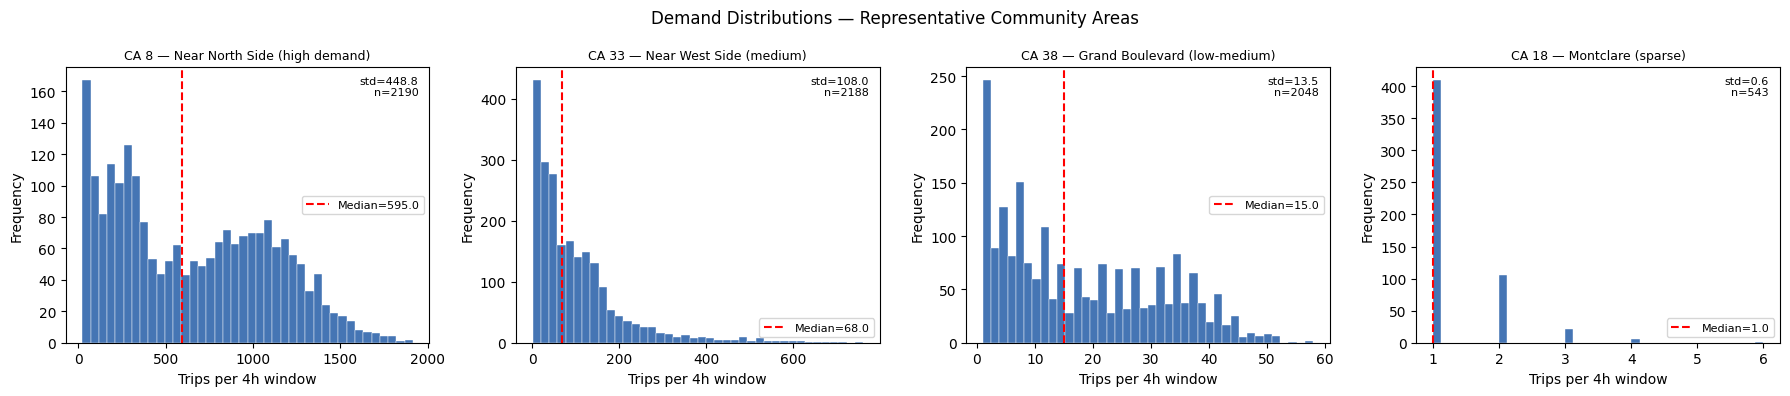

In [157]:
representative_areas = [8, 33, 38, 18]
labels = {
    8:  'CA 8 — Near North Side (high demand)',
    33: 'CA 33 — Near West Side (medium)',
    38: 'CA 38 — Grand Boulevard (low-medium)',
    18: 'CA 18 — Montclare (sparse)'
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, area in zip(axes, representative_areas):
    data = df_all[df_all['community_area'] == area]['count']
    med  = data.median()
    std  = data.std()
    ax.hist(data, bins=40, color='#4575b4', edgecolor='white', linewidth=0.3)
    ax.axvline(med, color='red', linestyle='--', linewidth=1.5, label=f'Median={med:.1f}')
    ax.set_title(labels[area], fontsize=9)
    ax.set_xlabel('Trips per 4h window')
    ax.set_ylabel('Frequency')
    ax.annotate(f'std={std:.1f}\nn={len(data)}', xy=(0.97, 0.97),
                xycoords='axes fraction', ha='right', va='top', fontsize=8)
    ax.legend(fontsize=8)

plt.suptitle('Demand Distributions — Representative Community Areas', fontsize=12)
plt.tight_layout()
plt.show()


### Why per-area models for sparse areas also fail

For CA 18, almost all values are 1–3 trips per window (std ≈ 1). This means the **total variance
of the target (SS_tot) is less than 2**. Recall how R² is computed:

$$R^2 = 1 - \frac{\sum(y_i - \hat{y}_i)^2}{\sum(y_i - \bar{y})^2} = 1 - \frac{SS_{res}}{SS_{tot}}$$

If the model predicts 2 when the true value is 1, or vice versa, each error contributes 1 to SS_res.
With SS_tot ≈ 1.5 and just a handful of such errors, SS_res > SS_tot and R² < 0.

This is not a model failure — it is a **data insufficiency**. No regression model trained on
time and weather features can outperform the trivial baseline (always predict the area mean)
when the target has this little variance. A classification approach ("will there be any trips?")
would be more appropriate but is outside the scope of this project.

The results from `03.01` confirmed this: the 10 worst areas had MSE < 2 (less than 1 trip off on average)
but R² between −0.8 and −1.7.


### 2.3 Spatial Distribution — Which Areas Are Included?

The map below shows the geographic distribution of included (blue) vs excluded (red) areas.
High-demand areas cluster around the downtown corridor, transit hubs, and O'Hare Airport (CA 76 in the northwest).


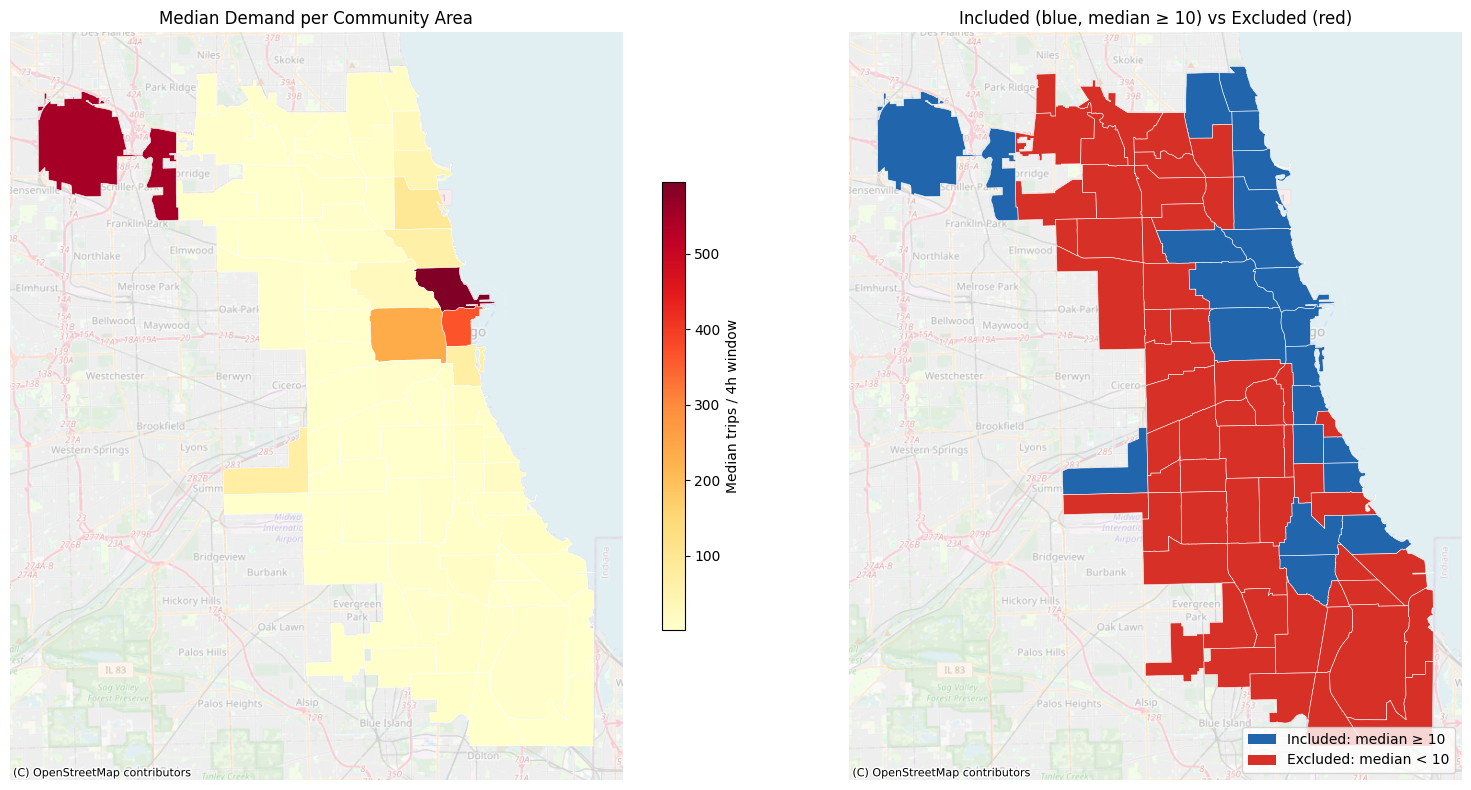

In [158]:
community_areas_gdf = gpd.read_file(COMMUNITY_AREAS_PATH)
community_areas_gdf['area_numbe'] = community_areas_gdf['area_numbe'].astype(int)
community_areas_gdf = community_areas_gdf.merge(
    area_stats[['community_area', 'median']],
    left_on='area_numbe', right_on='community_area', how='left'
)
community_areas_gdf['above_threshold'] = community_areas_gdf['median'] >= DEMAND_THRESHOLD
ca_web = community_areas_gdf.to_crs(epsg=3857)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: continuous median demand
ca_web.plot(ax=axes[0], column='median', cmap='YlOrRd', legend=True,
            legend_kwds={'label': 'Median trips / 4h window', 'shrink': 0.6},
            edgecolor='white', linewidth=0.4)
ctx.add_basemap(axes[0], crs=ca_web.crs,
                source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.35)
axes[0].set_title('Median Demand per Community Area')
axes[0].axis('off')

# Right: binary included / excluded
ca_web['color'] = ca_web['above_threshold'].map({True: '#2166ac', False: '#d73027'})
ca_web.plot(ax=axes[1], color=ca_web['color'], edgecolor='white', linewidth=0.4)
ctx.add_basemap(axes[1], crs=ca_web.crs,
                source=ctx.providers.OpenStreetMap.Mapnik, alpha=0.35)
axes[1].set_title(f'Included (blue, median ≥ {DEMAND_THRESHOLD}) vs Excluded (red)')
axes[1].legend(handles=[
    Patch(facecolor='#2166ac', label=f'Included: median ≥ {DEMAND_THRESHOLD}'),
    Patch(facecolor='#d73027', label=f'Excluded: median < {DEMAND_THRESHOLD}')
], loc='lower right')
axes[1].axis('off')

plt.tight_layout()
plt.show()


## 3. Area Selection — Applying the Demand Threshold

We select areas where the **median 4-hour demand is at least 10 trips**. The threshold of 10 is chosen
over a lower value (e.g. 5) for three concrete reasons:

1. **Empirical R² evidence** — in our initial per-area experiments with threshold = 5, every area
   with median demand below 10 produced R² below 0.5, with the weakest (median = 6) at just
   R² = 0.07. These areas contributed noise, not predictions, to the final model evaluation.

2. **Minimum interpretable signal** — 10 trips per 4-hour window corresponds to roughly 60 trips/day
   or ~2.5 trips/hour on average. Below this level, a single missed or extra trip moves the relative
   error by 10–50%, making any learned temporal pattern indistinguishable from random fluctuation.

3. **Natural break in the sorted distribution** — the bar chart above shows a visible inflection in
   the sorted median curve around 10–12 trips/window, consistent with two distinct demand regimes.

Areas below the threshold are **not discarded as unimportant** — they simply require a different
approach (e.g., binary classification "any demand or not", or a simple historical mean baseline).
For this notebook, we focus exclusively on regression for the included areas.


In [159]:
included_areas = sorted(area_stats[area_stats['median'] >= DEMAND_THRESHOLD]['community_area'].tolist())
excluded_areas = sorted(area_stats[area_stats['median'] <  DEMAND_THRESHOLD]['community_area'].tolist())

print(f"Areas included (median ≥ {DEMAND_THRESHOLD}): {len(included_areas)}")
print(f"Areas excluded (median <  {DEMAND_THRESHOLD}): {len(excluded_areas)}")
print()

included_stats = area_stats[area_stats['median'] > DEMAND_THRESHOLD].sort_values('median', ascending=False)
print("Included areas (sorted by median demand):")
print(included_stats[['community_area','median','mean','max','n_rows']].to_string(index=False))


Areas included (median ≥ 10): 21
Areas excluded (median <  10): 56

Included areas (sorted by median demand):
 community_area  median   mean  max  n_rows
              8   595.0 650.08 1916    2190
             76   547.5 561.31 1636    2190
             32   367.5 465.25 1548    2190
             28   236.0 291.16 1185    2190
              6    95.0  99.25  423    2190
             56    71.0  72.82  262    2189
             33    68.0 100.26  761    2188
              7    62.0  65.87  347    2171
              3    45.0  49.33  184    2186
             77    29.0  32.84  114    2179
             24    27.0  31.12  204    2175
             41    19.0  24.50   98    2014
              2    17.0  18.94   57    2179
             35    17.0  20.91   72    2122
             43    16.0  17.35   53    2142
             38    15.0  17.94   58    2048
             44    14.0  15.32   44    2168
              1    13.0  15.23   59    2184
             39    11.0  13.92   45    2039


## 4. Feature Set

POI features are excluded from per-area models because within a single area every POI column is constant
(all rows of CA 8 have the same `poi_amenity` value). A constant feature has zero variance,
which causes `StandardScaler` to divide by zero. The 13 features used are:

| Group | Features |
|---|---|
| Time (cyclic) | `hour_sin/cos`, `day_of_week_sin/cos`, `month_sin/cos` |
| Weather | `temperature_2m`, `precipitation`, `snowfall`, `wind_speed_10m`, `cloud_cover` |
| Binary flags | `is_weekend`, `is_holiday` |

The target is `log1p(count)` for both models. Within high-demand areas the count distribution
remains right-skewed (CA 8 ranges from ~10 to ~1,916 trips/window). The log-transform compresses
this tail and improves convergence. All reported metrics use `expm1`-transformed predictions
(original trip-count scale).


In [160]:
FEATURE_COLS = [
    'temperature_2m', 'precipitation', 'snowfall', 'wind_speed_10m', 'cloud_cover',
    'hour_sin', 'hour_cos', 'day_of_week_sin', 'day_of_week_cos',
    'month_sin', 'month_cos', 'is_weekend', 'is_holiday'
]


## 5. LinearSVR Baseline

Before applying a non-linear kernel, we establish a **linear baseline** using `LinearSVR`
(equivalent to an SVM with a linear kernel, but using a liblinear solver that scales as O(n)
rather than O(n²–n³)).

**Why a linear baseline first?**
- The assignment asks to start with a linear model before adding complexity
- A linear model is fully interpretable: the `coef_` vector (after scaling) directly quantifies
  how much each feature shifts the predicted demand. This is used as a proxy for feature importance.
- If the RBF model barely improves over the linear baseline, it suggests the underlying
  relationship is already close to linear and the extra kernel complexity is not warranted.

**Metric definitions:**
- **R²**: fraction of target variance explained (0 = predicting the mean, 1 = perfect, <0 = worse than mean)
- **MAE** (Mean Absolute Error): average absolute prediction error in trips
- **RMSE** (Root Mean Squared Error): like MAE but penalises large errors more; in the same unit as the target (trips)


In [161]:
print(f"Training LinearSVR baseline for {len(included_areas)} community areas...\n")

linear_results = []
linear_models  = {}
linear_y_test  = []
linear_y_pred  = []

for area in included_areas:
    df_area = df_all[df_all['community_area'] == area]

    X = df_area[FEATURE_COLS]
    y = np.log1p(df_area['count'])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('svm',    LinearSVR(C=1.0, epsilon=0.1, max_iter=5000, random_state=42))
    ])
    model.fit(X_train, y_train)

    y_pred_log  = model.predict(X_test)
    y_pred_area = np.expm1(y_pred_log)
    y_test_area = np.expm1(y_test)

    linear_results.append({
        'community_area': int(area),
        'median_demand':  round(df_area['count'].median(), 1),
        'n_train': len(X_train),
        'n_test':  len(X_test),
        'r2':   round(r2_score(y_test_area, y_pred_area), 4),
        'mae':  round(mean_absolute_error(y_test_area, y_pred_area), 2),
        'rmse': round(np.sqrt(mean_squared_error(y_test_area, y_pred_area)), 2),
    })
    linear_models[int(area)] = model
    linear_y_test.extend(y_test_area.values)
    linear_y_pred.extend(y_pred_area)

linear_df      = pd.DataFrame(linear_results)
linear_overall = r2_score(linear_y_test, linear_y_pred)
linear_mae     = mean_absolute_error(linear_y_test, linear_y_pred)
linear_rmse    = np.sqrt(mean_squared_error(linear_y_test, linear_y_pred))

print(f"LinearSVR — Overall R²  (pooled):  {linear_overall:.3f}")
print(f"LinearSVR — Overall MAE (pooled):  {linear_mae:.2f} trips")
print(f"LinearSVR — Overall RMSE (pooled): {linear_rmse:.2f} trips")
print(f"Median R² per area:                {linear_df['r2'].median():.3f}")
print(f"Mean R² per area:                  {linear_df['r2'].mean():.3f}")
print(f"\nFull results (sorted by R²):")
print(linear_df.sort_values('r2', ascending=False).to_string(index=False))


Training LinearSVR baseline for 21 community areas...



/Users/maikekatterbach/Documents/GitHub/AAA_Team_1/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVR — Overall R²  (pooled):  0.818
LinearSVR — Overall MAE (pooled):  41.61 trips
LinearSVR — Overall RMSE (pooled): 105.53 trips
Median R² per area:                0.674
Mean R² per area:                  0.610

Full results (sorted by R²):
 community_area  median_demand  n_train  n_test     r2    mae   rmse
             43           16.0     1713     429 0.8227   3.99   5.19
             38           15.0     1638     410 0.8003   4.32   6.18
             77           29.0     1743     436 0.7955   7.82  10.69
             41           19.0     1611     403 0.7937   6.09   8.94
             35           17.0     1697     425 0.7867   5.24   7.25
              2           17.0     1743     436 0.7691   4.47   5.64
              1           13.0     1747     437 0.7550   3.76   4.77
             39           11.0     1631     408 0.7330   3.83   5.39
             69           10.0     1696     424 0.6884   3.55   4.75
              8          595.0     1752     438 0.6786 189.84 

### LinearSVR Feature Importance (CA 8)

For a linear model trained on standardised features, **feature importance = |coefficient|**.
After `StandardScaler` all inputs have mean 0 and std 1, so the coefficients are directly
comparable: a coefficient of 0.8 shifts the log-demand prediction by 0.8 units regardless of
whether the original feature was temperature or a binary flag.

The sign of the coefficient tells you the direction (e.g. higher temperature → more trips),
but **magnitude** tells you how much the feature actually contributes. Features with near-zero
coefficients have almost no effect on the model's predictions and could potentially be dropped.


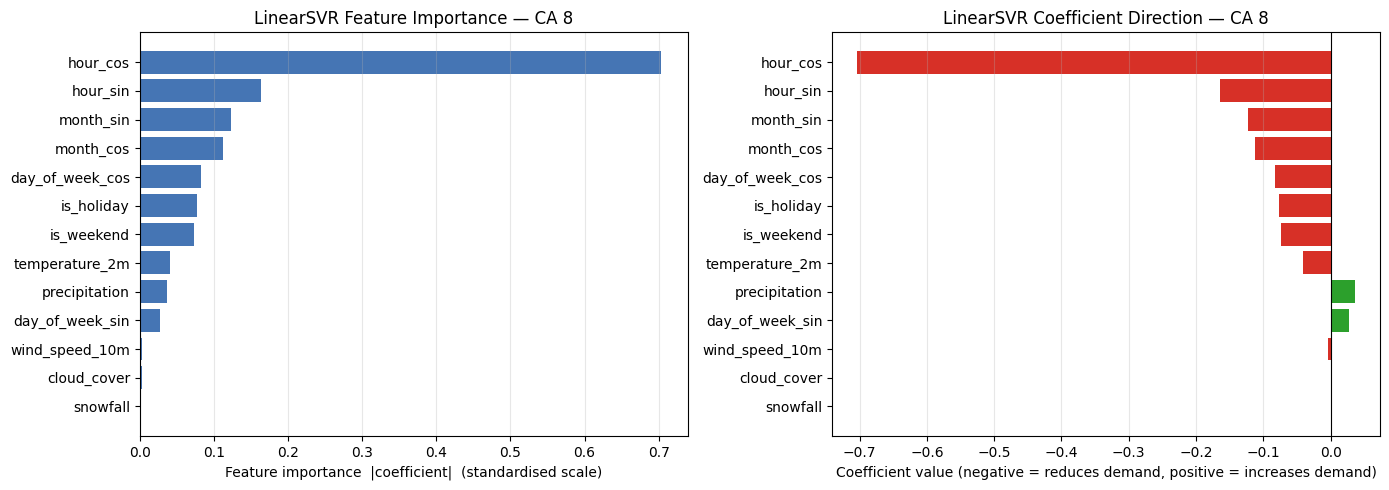

Top 5 most important features:
        feature  importance  coefficient
       hour_cos    0.703640    -0.703640
       hour_sin    0.164099    -0.164099
      month_sin    0.122925    -0.122925
      month_cos    0.112273    -0.112273
day_of_week_cos    0.082003    -0.082003


In [162]:
COEF_AREA = 8
linear_model_coef = linear_models[COEF_AREA]
coefs = linear_model_coef.named_steps['svm'].coef_  # shape (n_features,) for single-target LinearSVR

coef_df = pd.DataFrame({
    'feature':    FEATURE_COLS,
    'coefficient': coefs,
    'importance':  np.abs(coefs)
}).sort_values('importance', ascending=True)  # ascending so most important is at top of barh

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: importance (absolute value) — answers "how much does this feature contribute?"
axes[0].barh(coef_df['feature'], coef_df['importance'], color='#4575b4')
axes[0].set_xlabel('Feature importance  |coefficient|  (standardised scale)')
axes[0].set_title(f'LinearSVR Feature Importance — CA {COEF_AREA}')
axes[0].grid(axis='x', alpha=0.3)

# Right: raw coefficient — answers "in which direction?"
colors_dir = ['#d73027' if c < 0 else '#2ca02c' for c in coef_df['coefficient']]
axes[1].barh(coef_df['feature'], coef_df['coefficient'], color=colors_dir)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Coefficient value (negative = reduces demand, positive = increases demand)')
axes[1].set_title(f'LinearSVR Coefficient Direction — CA {COEF_AREA}')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

print("Top 5 most important features:")
print(coef_df[['feature','importance','coefficient']].tail(5).iloc[::-1].to_string(index=False))


## 6. Per-Area RBF SVR

The RBF (Gaussian) kernel SVR is the main model. Unlike the linear baseline, it can learn
**non-linear demand patterns** — for example, rush-hour spikes are sharp peaks that linear
models systematically underestimate.

Standard SVR with a kernel scales as O(n²)–O(n³) in training time. With all 77 areas combined
(~137k rows) this is impractical. With per-area datasets of ~400–1,750 rows, training takes
seconds per area (~1–2 minutes total). This is a direct advantage of the per-area approach.

Hyperparameters used: `C=100, gamma='scale', epsilon=0.1`. GridSearch to refine these is
shown in Section 8.


In [163]:
print(f"Training RBF SVR for {len(included_areas)} community areas...\n")

area_results = []
models       = {}
all_y_test   = []
all_y_pred   = []

for area in included_areas:
    df_area = df_all[df_all['community_area'] == area]

    X = df_area[FEATURE_COLS]
    y = np.log1p(df_area['count'])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('svm',    SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1))
    ])
    model.fit(X_train, y_train)

    y_pred_area = np.expm1(model.predict(X_test))
    y_test_area = np.expm1(y_test)

    area_results.append({
        'community_area': int(area),
        'median_demand':  round(df_area['count'].median(), 1),
        'n_train': len(X_train),
        'n_test':  len(X_test),
        'r2':   round(r2_score(y_test_area, y_pred_area), 4),
        'mae':  round(mean_absolute_error(y_test_area, y_pred_area), 2),
        'rmse': round(np.sqrt(mean_squared_error(y_test_area, y_pred_area)), 2),
    })
    models[int(area)] = model
    all_y_test.extend(y_test_area.values)
    all_y_pred.extend(y_pred_area)

results_df   = pd.DataFrame(area_results)
overall_r2   = r2_score(all_y_test, all_y_pred)
overall_mae  = mean_absolute_error(all_y_test, all_y_pred)
overall_rmse = np.sqrt(mean_squared_error(all_y_test, all_y_pred))

print(f"RBF SVR — Overall R²   (pooled):  {overall_r2:.3f}")
print(f"RBF SVR — Overall MAE  (pooled):  {overall_mae:.2f} trips")
print(f"RBF SVR — Overall RMSE (pooled):  {overall_rmse:.2f} trips")
print(f"Median R² per area:               {results_df['r2'].median():.3f}")
print(f"Mean R² per area:                 {results_df['r2'].mean():.3f}")
print(f"Areas with R² > 0.7:              {(results_df['r2'] > 0.7).sum()}")
print(f"Areas with R² > 0.5:              {(results_df['r2'] > 0.5).sum()}")
print(f"Areas with R² < 0:                {(results_df['r2'] < 0).sum()}")
print(f"\nFull results (sorted by R²):")
print(results_df.sort_values('r2', ascending=False).to_string(index=False))


Training RBF SVR for 21 community areas...

RBF SVR — Overall R²   (pooled):  0.910
RBF SVR — Overall MAE  (pooled):  27.72 trips
RBF SVR — Overall RMSE (pooled):  74.12 trips
Median R² per area:               0.726
Mean R² per area:                 0.645
Areas with R² > 0.7:              11
Areas with R² > 0.5:              16
Areas with R² < 0:                0

Full results (sorted by R²):
 community_area  median_demand  n_train  n_test     r2    mae   rmse
             28          236.0     1752     438 0.8716  56.89  90.18
             32          367.5     1752     438 0.8422  89.86 141.04
             38           15.0     1638     410 0.8160   4.10   5.94
              8          595.0     1752     438 0.8036 119.92 190.51
             41           19.0     1611     403 0.7893   6.04   9.03
             43           16.0     1713     429 0.7817   4.16   5.75
             35           17.0     1697     425 0.7647   5.29   7.62
             77           29.0     1743     436 0.76

## 7. Model Comparison: LinearSVR vs RBF SVR

The table below summarises the aggregate metrics for both models.
Per-area R² improvements are visualised in the chart.


In [164]:
# Summary table
comparison = pd.DataFrame({
    'Model':        ['LinearSVR baseline', 'RBF SVR'],
    'Pooled R²':    [round(linear_overall, 3), round(overall_r2, 3)],
    'Pooled MAE':   [round(linear_mae, 2),   round(overall_mae, 2)],
    'Pooled RMSE':  [round(linear_rmse, 2),  round(overall_rmse, 2)],
    'Median R² / area': [round(linear_df['r2'].median(), 3), round(results_df['r2'].median(), 3)],
    'Mean R² / area':   [round(linear_df['r2'].mean(), 3),   round(results_df['r2'].mean(), 3)],
})
print(comparison.to_string(index=False))


             Model  Pooled R²  Pooled MAE  Pooled RMSE  Median R² / area  Mean R² / area
LinearSVR baseline      0.818       41.61       105.53             0.674           0.610
           RBF SVR      0.910       27.72        74.12             0.726           0.645


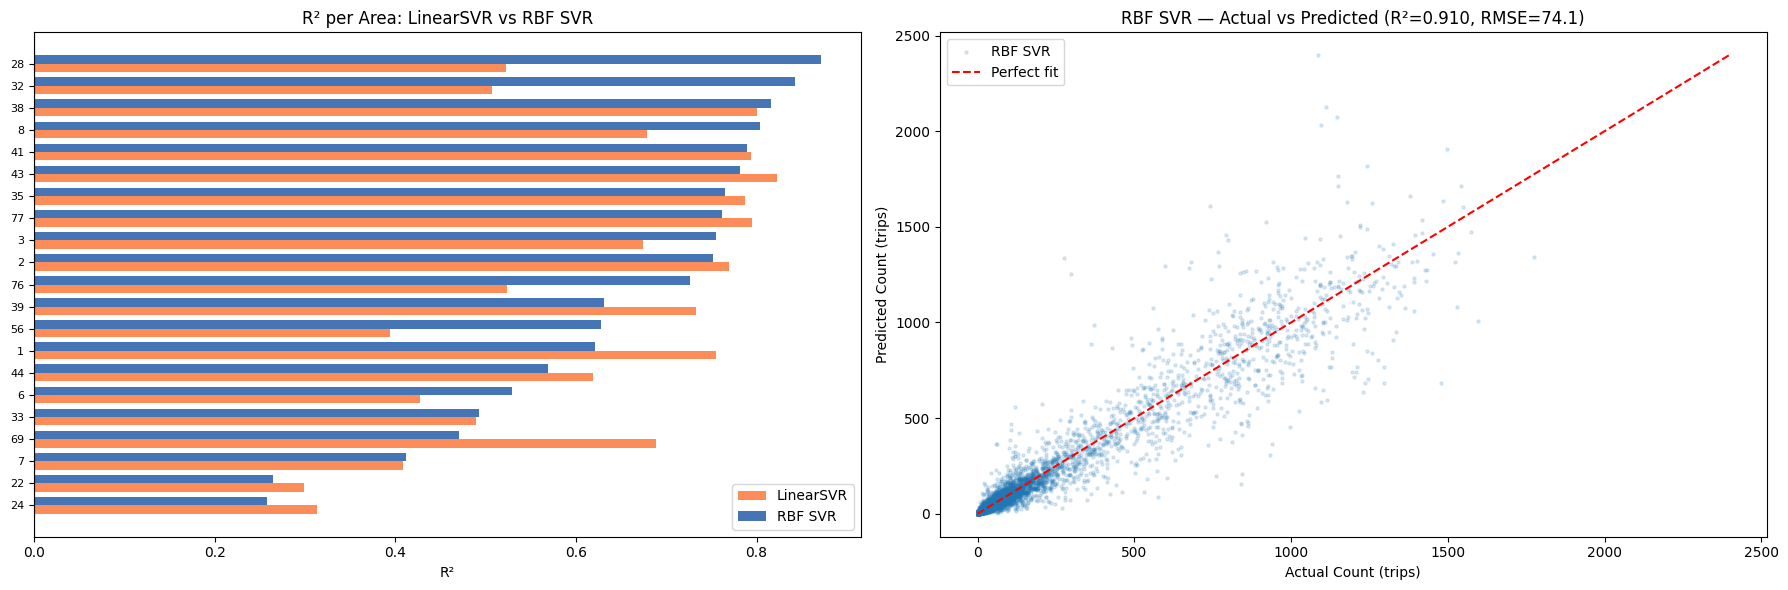

In [165]:
# Per-area R² comparison
merged = linear_df[['community_area','r2']].rename(columns={'r2':'r2_linear'}).merge(
    results_df[['community_area','r2']].rename(columns={'r2':'r2_rbf'}),
    on='community_area'
).sort_values('r2_rbf')

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

x = np.arange(len(merged))
width = 0.38
axes[0].barh(x - width/2, merged['r2_linear'], width, label='LinearSVR', color='#fc8d59')
axes[0].barh(x + width/2, merged['r2_rbf'],    width, label='RBF SVR',   color='#4575b4')
axes[0].set_yticks(x)
axes[0].set_yticklabels(merged['community_area'].astype(str), fontsize=8)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('R²')
axes[0].set_title('R² per Area: LinearSVR vs RBF SVR')
axes[0].legend()

# Actual vs predicted for RBF
axes[1].scatter(all_y_test, all_y_pred, alpha=0.15, s=5, label='RBF SVR')
max_val = max(max(all_y_test), max(all_y_pred))
axes[1].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect fit')
axes[1].set_xlabel('Actual Count (trips)')
axes[1].set_ylabel('Predicted Count (trips)')
axes[1].set_title(f'RBF SVR — Actual vs Predicted (R²={overall_r2:.3f}, RMSE={overall_rmse:.1f})')
axes[1].legend()

plt.tight_layout()
plt.show()


### R² as a Function of Area Demand Level

The scatter below checks whether model quality correlates with the area's demand level.
We expect higher-demand areas to perform better: their count distributions have more
variance for the model to explain, and their temporal patterns (rush hour, weekday/weekend)
are stronger relative to random noise.


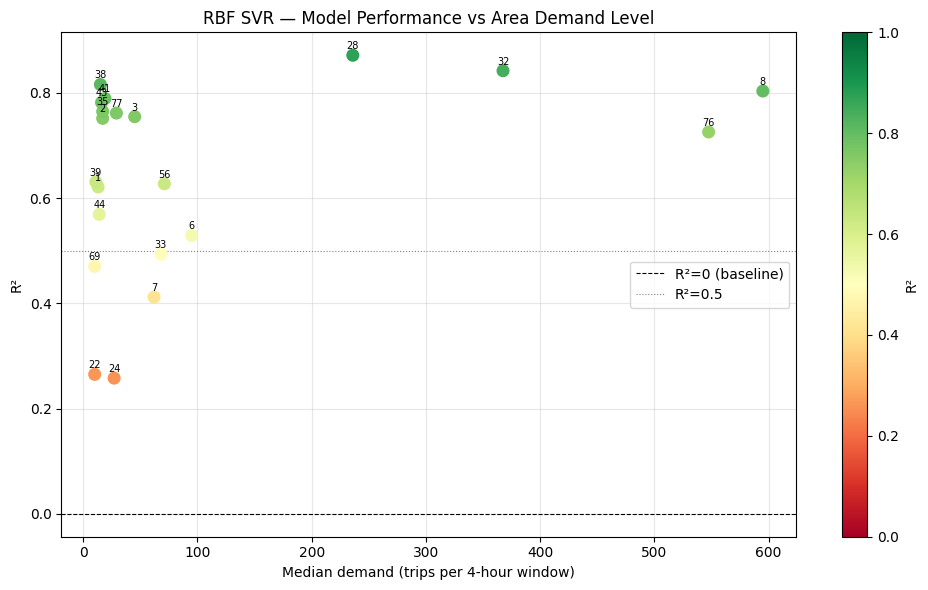

In [166]:
fig, ax = plt.subplots(figsize=(10, 6))

sc = ax.scatter(results_df['median_demand'], results_df['r2'],
                c=results_df['r2'], cmap='RdYlGn', s=70, vmin=0, vmax=1, zorder=3)
plt.colorbar(sc, ax=ax, label='R²')

for _, row in results_df.iterrows():
    ax.annotate(str(int(row['community_area'])),
                (row['median_demand'], row['r2']),
                fontsize=7, ha='center', va='bottom', xytext=(0, 3),
                textcoords='offset points')

ax.axhline(0,   color='black', linewidth=0.8, linestyle='--', label='R²=0 (baseline)')
ax.axhline(0.5, color='grey',  linewidth=0.8, linestyle=':',  label='R²=0.5')
ax.set_xlabel('Median demand (trips per 4-hour window)')
ax.set_ylabel('R²')
ax.set_title('RBF SVR — Model Performance vs Area Demand Level')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 8. Hyperparameter Tuning (GridSearch)

With per-area datasets of ~1,400–1,750 rows, a full kernel SVR GridSearch is feasible
**without any subsampling** — one of the key advantages of the per-area approach.
The grid is intentionally narrowed to `rbf` only and a smaller parameter space
(12 combinations × 5 folds = 60 fits, ~1–3 minutes per area).

Change `AREA_ID` to tune a different area. Uncomment the fit block to run.


In [167]:
AREA_ID = 8

df_area_gs    = df_all[df_all['community_area'] == AREA_ID]
X_gs          = df_area_gs[FEATURE_COLS]
y_gs          = np.log1p(df_area_gs['count'])

X_train_gs, X_test_gs, y_train_gs, y_test_gs = train_test_split(
    X_gs, y_gs, test_size=0.2, random_state=42
)

pipeline_gs = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    SVR())
])

param_grid = {
    'svm__C':       [10, 100, 1000],
    'svm__epsilon': [0.01, 0.1],
    'svm__gamma':   ['scale', 0.01],
    'svm__kernel':  ['rbf']      # linear/poly/sigmoid can be added but are much slower
}

grid_search_area = GridSearchCV(
    estimator=pipeline_gs, param_grid=param_grid,
    cv=5, scoring='r2', n_jobs=-1
)

# grid_search_area.fit(X_train_gs, y_train_gs)
# print(f"Best params for CA {AREA_ID}:", grid_search_area.best_params_)
# print(f"Best CV R²: {grid_search_area.best_score_:.3f}")
# y_pred_gs     = np.expm1(grid_search_area.predict(X_test_gs))
# y_test_gs_act = np.expm1(y_test_gs)
# print(f"Test R²:   {r2_score(y_test_gs_act, y_pred_gs):.3f}")
# print(f"Test MAE:  {mean_absolute_error(y_test_gs_act, y_pred_gs):.2f} trips")
# print(f"Test RMSE: {np.sqrt(mean_squared_error(y_test_gs_act, y_pred_gs)):.2f} trips")


## 9. Hyperparameter Tuning — All Included Areas

### Design choices for computational feasibility

Running a full GridSearch across all included areas requires careful scoping to stay within
a reasonable runtime on a standard laptop. The following choices keep total training time
under ~5 minutes:

| Setting | Value | Reason |
|---|---|---|
| CV folds | 3 | 5-fold doubles runtime vs 3-fold with little extra stability for ~1,500-row datasets |
| `n_jobs=-1` | all CPU cores | parallelises the fold fits within each area's GridSearch |
| Grid size (LinearSVR) | 10 combinations | `C` × `epsilon` only; `max_iter` is fixed high enough to converge |
| Grid size (RBF SVR) | 6 combinations | `C` × `gamma` only; `epsilon` fixed at 0.1 |

The grids are asymmetric because LinearSVR is O(n) and trivially fast; RBF SVR is O(n²–n³)
per fit and benefits more from a narrower grid.

**Important:** GridSearch is scored on the **log-transformed target** (since the model trains
on `log1p(count)`). The best parameters are then used to refit and evaluate on the original
count scale with MAE, RMSE, and R².


In [168]:
from sklearn.model_selection import GridSearchCV

# ── Grid definitions ──────────────────────────────────────────────────────────
linear_param_grid = {
    'svm__C':       [0.01, 0.1, 1, 10, 100],
    'svm__epsilon': [0.01, 0.1],
}

rbf_param_grid = {
    'svm__C':       [10, 100, 1000],
    'svm__gamma':   ['scale', 0.01],
    'svm__epsilon': [0.1],
    'svm__kernel':  ['rbf'],
}

print("Grid sizes:")
n_linear = len(linear_param_grid['svm__C']) * len(linear_param_grid['svm__epsilon'])
n_rbf    = len(rbf_param_grid['svm__C']) * len(rbf_param_grid['svm__gamma']) * len(rbf_param_grid['svm__epsilon'])
print(f"  LinearSVR: {n_linear} combinations × 3 folds × {len(included_areas)} areas = {n_linear * 3 * len(included_areas)} fits")
print(f"  RBF SVR:   {n_rbf}  combinations × 3 folds × {len(included_areas)} areas = {n_rbf * 3 * len(included_areas)} fits")


Grid sizes:
  LinearSVR: 10 combinations × 3 folds × 21 areas = 630 fits
  RBF SVR:   6  combinations × 3 folds × 21 areas = 378 fits


In [169]:
import time

# ── LinearSVR GridSearch ───────────────────────────────────────────────────────
print("Running LinearSVR GridSearch...\n")
t0 = time.time()

gs_linear_results = []
gs_linear_models  = {}

for area in included_areas:
    df_area = df_all[df_all['community_area'] == area]
    X = df_area[FEATURE_COLS]
    y = np.log1p(df_area['count'])

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('svm',    LinearSVR(max_iter=10000, random_state=42))
    ])
    gs = GridSearchCV(pipe, linear_param_grid, cv=3, scoring='r2', n_jobs=-1)
    gs.fit(X_train, y_train)

    y_pred_area = np.expm1(gs.predict(X_test))
    y_test_area = np.expm1(y_test)

    gs_linear_results.append({
        'community_area': int(area),
        'median_demand':  round(df_area['count'].median(), 1),
        'best_C':         gs.best_params_['svm__C'],
        'best_epsilon':   gs.best_params_['svm__epsilon'],
        'cv_r2':          round(gs.best_score_, 4),
        'test_r2':        round(r2_score(y_test_area, y_pred_area), 4),
        'test_mae':       round(mean_absolute_error(y_test_area, y_pred_area), 2),
        'test_rmse':      round(np.sqrt(mean_squared_error(y_test_area, y_pred_area)), 2),
    })
    gs_linear_models[int(area)] = gs.best_estimator_

gs_linear_df = pd.DataFrame(gs_linear_results)
print(f"Done in {time.time() - t0:.1f}s")
print(f"\nTuned LinearSVR — Median R²: {gs_linear_df['test_r2'].median():.3f}  |  Mean R²: {gs_linear_df['test_r2'].mean():.3f}")
print(f"Most common best C:       {gs_linear_df['best_C'].mode()[0]}")
print(f"Most common best epsilon: {gs_linear_df['best_epsilon'].mode()[0]}")


Running LinearSVR GridSearch...



/Users/maikekatterbach/Documents/GitHub/AAA_Team_1/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/maikekatterbach/Documents/GitHub/AAA_Team_1/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/maikekatterbach/Documents/GitHub/AAA_Team_1/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/maikekatterbach/Documents/GitHub/AAA_Team_1/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/maikekatterbach/Documents/GitHub/AAA_Team_1/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Libline

Done in 57.1s

Tuned LinearSVR — Median R²: 0.673  |  Mean R²: 0.610
Most common best C:       0.1
Most common best epsilon: 0.1


/Users/maikekatterbach/Documents/GitHub/AAA_Team_1/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/maikekatterbach/Documents/GitHub/AAA_Team_1/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/maikekatterbach/Documents/GitHub/AAA_Team_1/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/Users/maikekatterbach/Documents/GitHub/AAA_Team_1/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [170]:
# ── RBF SVR GridSearch ────────────────────────────────────────────────────────
print("Running RBF SVR GridSearch (this takes longer)...\n")
t0 = time.time()

gs_rbf_results = []
gs_rbf_models  = {}

for area in included_areas:
    df_area = df_all[df_all['community_area'] == area]
    X = df_area[FEATURE_COLS]
    y = np.log1p(df_area['count'])

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('svm',    SVR())
    ])
    gs = GridSearchCV(pipe, rbf_param_grid, cv=3, scoring='r2', n_jobs=-1)
    gs.fit(X_train, y_train)

    y_pred_area = np.expm1(gs.predict(X_test))
    y_test_area = np.expm1(y_test)

    gs_rbf_results.append({
        'community_area': int(area),
        'median_demand':  round(df_area['count'].median(), 1),
        'best_C':         gs.best_params_['svm__C'],
        'best_gamma':     gs.best_params_['svm__gamma'],
        'cv_r2':          round(gs.best_score_, 4),
        'test_r2':        round(r2_score(y_test_area, y_pred_area), 4),
        'test_mae':       round(mean_absolute_error(y_test_area, y_pred_area), 2),
        'test_rmse':      round(np.sqrt(mean_squared_error(y_test_area, y_pred_area)), 2),
    })
    gs_rbf_models[int(area)] = gs.best_estimator_

gs_rbf_df = pd.DataFrame(gs_rbf_results)
print(f"Done in {time.time() - t0:.1f}s")
print(f"\nTuned RBF SVR — Median R²: {gs_rbf_df['test_r2'].median():.3f}  |  Mean R²: {gs_rbf_df['test_r2'].mean():.3f}")
print(f"Most common best C:     {gs_rbf_df['best_C'].mode()[0]}")
print(f"Most common best gamma: {gs_rbf_df['best_gamma'].mode()[0]}")


Running RBF SVR GridSearch (this takes longer)...

Done in 129.6s

Tuned RBF SVR — Median R²: 0.818  |  Mean R²: 0.774
Most common best C:     100
Most common best gamma: 0.01


### Results: Default vs Tuned


In [171]:
# Summary table: default vs tuned
summary = pd.DataFrame({
    'Model':           ['LinearSVR (default)', 'LinearSVR (tuned)', 'RBF SVR (default)', 'RBF SVR (tuned)'],
    'Median R²/area':  [
        round(linear_df['r2'].median(), 3),
        round(gs_linear_df['test_r2'].median(), 3),
        round(results_df['r2'].median(), 3),
        round(gs_rbf_df['test_r2'].median(), 3),
    ],
    'Mean R²/area': [
        round(linear_df['r2'].mean(), 3),
        round(gs_linear_df['test_r2'].mean(), 3),
        round(results_df['r2'].mean(), 3),
        round(gs_rbf_df['test_r2'].mean(), 3),
    ],
    'Median MAE/area': [
        round(linear_df['mae'].median(), 2),
        round(gs_linear_df['test_mae'].median(), 2),
        round(results_df['mae'].median(), 2),
        round(gs_rbf_df['test_mae'].median(), 2),
    ],
})
print(summary.to_string(index=False))


              Model  Median R²/area  Mean R²/area  Median MAE/area
LinearSVR (default)           0.674         0.610             7.82
  LinearSVR (tuned)           0.673         0.610             7.81
  RBF SVR (default)           0.726         0.645             7.69
    RBF SVR (tuned)           0.818         0.774             5.54


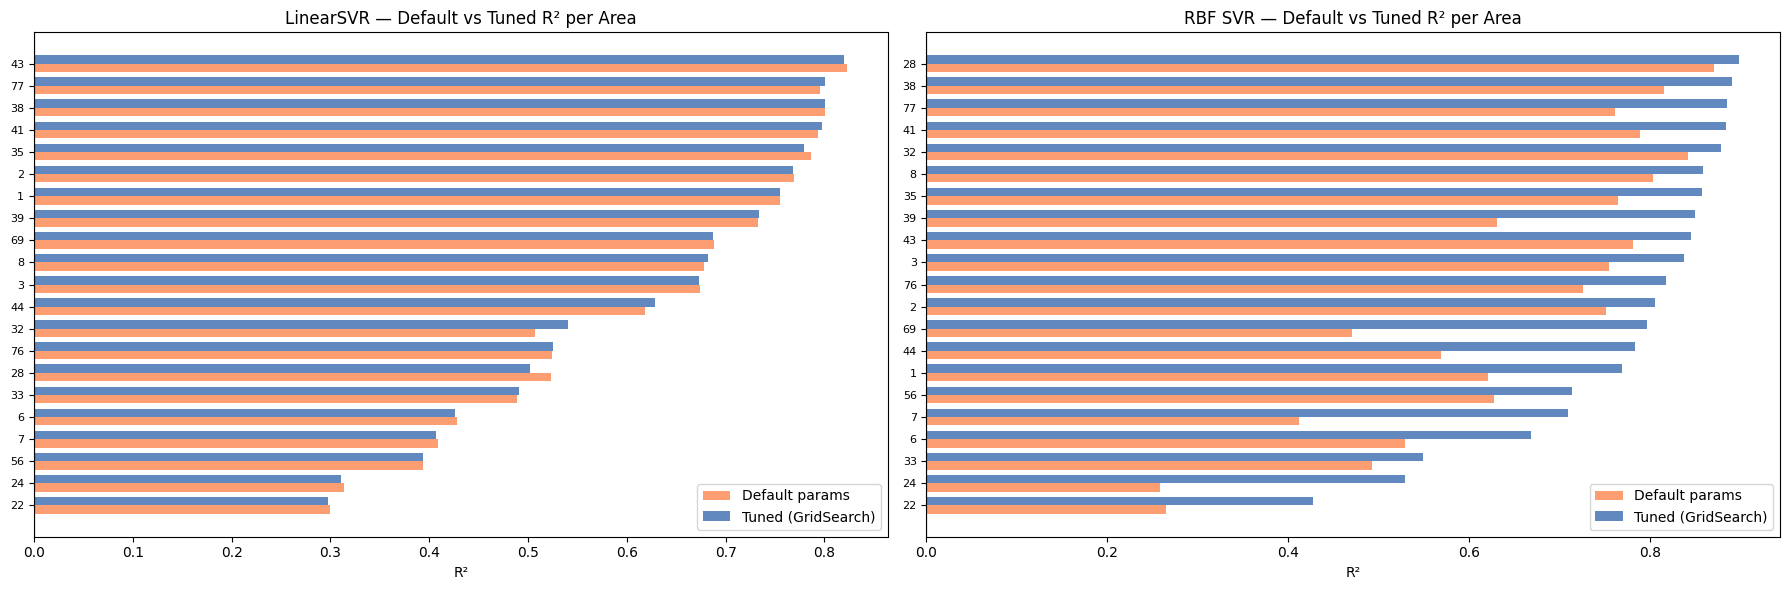

In [172]:
# Per-area R² improvement: default vs tuned for both models
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for ax, (default_df, tuned_df, title) in zip(axes, [
    (linear_df,  gs_linear_df, 'LinearSVR'),
    (results_df, gs_rbf_df,    'RBF SVR'),
]):
    merged = (
        default_df[['community_area', 'r2']].rename(columns={'r2': 'default'})
        .merge(tuned_df[['community_area', 'test_r2']].rename(columns={'test_r2': 'tuned'}),
               on='community_area')
        .sort_values('tuned')
    )
    x = np.arange(len(merged))
    w = 0.38
    ax.barh(x - w/2, merged['default'], w, label='Default params', color='#fc8d59', alpha=0.85)
    ax.barh(x + w/2, merged['tuned'],   w, label='Tuned (GridSearch)', color='#4575b4', alpha=0.85)
    ax.set_yticks(x)
    ax.set_yticklabels(merged['community_area'].astype(str), fontsize=8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('R²')
    ax.set_title(f'{title} — Default vs Tuned R² per Area')
    ax.legend()

plt.tight_layout()
plt.show()


In [173]:
# Best hyperparameters per area (RBF SVR)
print("Best hyperparameters per area — RBF SVR:")
print(gs_rbf_df[['community_area','median_demand','best_C','best_gamma','cv_r2','test_r2','test_mae','test_rmse']]
      .sort_values('test_r2', ascending=False).to_string(index=False))


Best hyperparameters per area — RBF SVR:
 community_area  median_demand  best_C best_gamma  cv_r2  test_r2  test_mae  test_rmse
             28          236.0      10      scale 0.9026   0.8991     49.38      79.92
             38           15.0      10       0.01 0.8882   0.8915      3.19       4.56
             77           29.0     100       0.01 0.8831   0.8850      5.54       8.01
             41           19.0      10       0.01 0.9109   0.8838      4.57       6.71
             32          367.5      10      scale 0.9207   0.8790     79.60     123.51
              8          595.0      10      scale 0.9060   0.8591    105.01     161.37
             35           17.0     100       0.01 0.8873   0.8575      4.02       5.93
             39           11.0      10       0.01 0.8581   0.8497      2.95       4.04
             43           16.0     100       0.01 0.8446   0.8455      3.43       4.84
              3           45.0     100       0.01 0.8791   0.8379     10.13      15.71
  

## 10. Handling Excluded Areas (Median Demand ≤ 10)

The areas excluded from the per-area SVR models are not simply ignored — they represent real
locations where taxis do occasionally operate. Two approaches are evaluated here:

**Approach A — Historical mean baseline**
For each excluded area, predict the training-set mean for every test window. This is the
theoretically correct lower bound: since these areas have near-zero variance in their target,
no regression model should be able to beat the mean prediction by much. R² will be close to
zero (by construction), but MAE and RMSE will be interpretable in real trip counts.

**Approach B — Pooled LinearSVR with area fixed effects**
All excluded areas are combined into a single dataset. Because they all share the same demand
scale (0–10 trips/window), the scale problem that broke the global model in `03.01` does not
apply here. Community area is one-hot encoded as area fixed effects so the model can learn
a baseline level per area while sharing the time and weather coefficients across areas.

We use LinearSVR rather than RBF SVR for this pooled model because:
- The dataset is large enough (all excluded areas combined) that RBF would be slow
- Low-demand areas likely have approximately linear temporal structure (modest rush-hour peaks)
- LinearSVR coefficients remain interpretable

**What to expect:** Neither approach will produce high R². The goal is to confirm that Approach A
(mean baseline) already achieves near-optimal performance for these areas, and that Approach B
adds some temporal signal but not dramatically more.


In [174]:
# Data for excluded areas
df_excluded = df_all[df_all['community_area'].isin(excluded_areas)].copy()

excluded_stats = (
    df_excluded.groupby('community_area')['count']
    .agg(median='median', mean='mean', std='std', n_rows='count')
    .reset_index()
    .sort_values('median', ascending=False)
)
print(f"Excluded areas: {len(excluded_areas)}, total rows: {len(df_excluded)}")
print(excluded_stats.to_string(index=False))


Excluded areas: 56, total rows: 92471
 community_area  median      mean      std  n_rows
             53     9.0  9.477762 6.299758    2091
             49     9.0  9.114948 5.462910    2114
              4     8.0 10.243985 7.418740    2078
             16     7.0  8.520019 5.764131    2123
             42     7.0  8.433317 6.413257    1987
             34     7.0  8.538246 5.628027    2144
             68     6.0  7.443249 5.240866    2044
              5     6.0  7.316591 4.880004    1971
             36     6.0  7.000529 5.012161    1890
             46     6.0  6.455544 4.441386    1912
             51     5.0  5.249603 3.432074    1887
             31     5.0  5.890425 3.988877    1953
             73     5.0  5.507268 3.538628    1995
             71     5.0  6.099222 4.377545    2056
             10     5.0  5.763405 3.320666    2126
             50     5.0  5.293467 3.481523    1898
             75     5.0  6.348814 4.614206    1981
             25     5.0  6.090164 4.158471  

### Approach A — Historical Mean Baseline


In [175]:
mean_baseline_results = []

for area in excluded_areas:
    df_area = df_all[df_all['community_area'] == area]
    y = df_area['count'].values

    # 80/20 split (same seed as rest of notebook)
    n_train = int(len(y) * 0.8)
    y_train, y_test = y[:n_train], y[n_train:]   # positional split preserves time order within area

    train_mean = y_train.mean()
    y_pred = np.full_like(y_test, fill_value=train_mean, dtype=float)

    mean_baseline_results.append({
        'community_area': int(area),
        'median_demand':  round(df_area['count'].median(), 1),
        'train_mean':     round(train_mean, 2),
        'n_test':         len(y_test),
        'r2':   round(r2_score(y_test, y_pred), 4),
        'mae':  round(mean_absolute_error(y_test, y_pred), 2),
        'rmse': round(np.sqrt(mean_squared_error(y_test, y_pred)), 2),
    })

mean_baseline_df = pd.DataFrame(mean_baseline_results)
print("Mean Baseline — per-area results (sorted by median demand):")
print(mean_baseline_df.sort_values('median_demand', ascending=False).to_string(index=False))
print(f"\nMedian MAE:  {mean_baseline_df['mae'].median():.2f} trips")
print(f"Median RMSE: {mean_baseline_df['rmse'].median():.2f} trips")
print(f"Median R²:   {mean_baseline_df['r2'].median():.3f}")


Mean Baseline — per-area results (sorted by median demand):
 community_area  median_demand  train_mean  n_test      r2  mae  rmse
             53            9.0       10.52     419 -2.2784 5.47  6.26
             49            9.0        9.73     423 -0.5773 4.36  5.08
              4            8.0       10.29     416 -0.0009 6.24  7.42
             16            7.0        8.94     425 -0.2186 4.34  5.01
             42            7.0        8.78     398 -0.1004 5.05  5.81
             34            7.0        8.87     429 -0.1064 4.57  5.41
             68            6.0        8.11     409 -1.1463 3.99  4.57
              5            6.0        7.37     395 -0.0033 4.04  4.94
             36            6.0        7.49     378 -0.4356 3.92  4.46
             46            6.0        6.88     383 -0.3383 3.74  4.24
             51            5.0        5.67     378 -0.8772 2.65  3.05
             31            5.0        5.69     391 -0.0468 3.58  4.81
             73            5.0

### Approach B — Pooled LinearSVR with One-Hot Area Encoding


In [176]:
# One-hot encode community_area before splitting so both sets share identical columns
df_pooled = df_excluded[FEATURE_COLS + ['community_area', 'count']].copy()
area_dummies = pd.get_dummies(df_pooled['community_area'], prefix='area', drop_first=True)
df_pooled = pd.concat([df_pooled.drop(columns=['community_area']), area_dummies], axis=1)

pooled_feature_cols = FEATURE_COLS + list(area_dummies.columns)

X_pool = df_pooled[pooled_feature_cols]
y_pool = np.log1p(df_pooled['count'])

X_train_pool, X_test_pool, y_train_pool, y_test_pool = train_test_split(
    X_pool, y_pool, test_size=0.2, random_state=42
)

pooled_model = Pipeline([
    ('scaler', StandardScaler()),
    ('svm',    LinearSVR(C=1.0, epsilon=0.1, max_iter=10000, random_state=42))
])
pooled_model.fit(X_train_pool, y_train_pool)

y_pred_pool = np.expm1(pooled_model.predict(X_test_pool))
y_test_pool_orig = np.expm1(y_test_pool)

overall_pool_r2   = r2_score(y_test_pool_orig, y_pred_pool)
overall_pool_mae  = mean_absolute_error(y_test_pool_orig, y_pred_pool)
overall_pool_rmse = np.sqrt(mean_squared_error(y_test_pool_orig, y_pred_pool))

print(f"Pooled LinearSVR — Overall R²:   {overall_pool_r2:.3f}")
print(f"Pooled LinearSVR — Overall MAE:  {overall_pool_mae:.2f} trips")
print(f"Pooled LinearSVR — Overall RMSE: {overall_pool_rmse:.2f} trips")


Pooled LinearSVR — Overall R²:   0.596
Pooled LinearSVR — Overall MAE:  1.89 trips
Pooled LinearSVR — Overall RMSE: 2.78 trips


/Users/maikekatterbach/Documents/GitHub/AAA_Team_1/.venv/lib/python3.13/site-packages/sklearn/svm/_base.py:1298: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


In [177]:
# Per-area breakdown for pooled model — reconstruct area column from dummies in test set
X_test_reset   = X_test_pool.reset_index(drop=True)
y_test_reset   = y_test_pool_orig.reset_index(drop=True)
y_pred_reset   = pd.Series(y_pred_pool)

# Recover area from dummy columns
dummy_cols = [c for c in X_test_reset.columns if c.startswith('area_')]
# area = max dummy col that is 1, or drop_first base area if all are 0
base_area = excluded_areas[0]

def recover_area(row):
    for col in dummy_cols:
        if row[col] > 0.5:
            return int(col.split('_')[1])
    return base_area

test_areas = X_test_reset.apply(recover_area, axis=1)

pooled_per_area = []
for area in excluded_areas:
    mask = test_areas == area
    if mask.sum() == 0:
        continue
    yt = y_test_reset[mask]
    yp = y_pred_reset[mask]
    pooled_per_area.append({
        'community_area': int(area),
        'median_demand':  round(df_all[df_all['community_area'] == area]['count'].median(), 1),
        'n_test': mask.sum(),
        'r2':   round(r2_score(yt, yp), 4),
        'mae':  round(mean_absolute_error(yt, yp), 2),
        'rmse': round(np.sqrt(mean_squared_error(yt, yp)), 2),
    })

pooled_per_area_df = pd.DataFrame(pooled_per_area)
print("Pooled LinearSVR — per-area results:")
print(pooled_per_area_df.sort_values('median_demand', ascending=False).to_string(index=False))
print(f"\nMedian MAE:  {pooled_per_area_df['mae'].median():.2f} trips")
print(f"Median RMSE: {pooled_per_area_df['rmse'].median():.2f} trips")
print(f"Median R²:   {pooled_per_area_df['r2'].median():.3f}")


Pooled LinearSVR — per-area results:
 community_area  median_demand  n_test      r2  mae  rmse
             53            9.0     428  0.4658 3.57  4.49
             49            9.0     453  0.5520 2.95  3.75
              4            8.0     392  0.5416 3.94  5.23
             16            7.0     399  0.5899 2.72  3.56
             42            7.0     397  0.5329 3.18  4.26
             34            7.0     465  0.2569 3.52  4.76
             68            6.0     412  0.5467 2.72  3.57
              5            6.0     402  0.4054 2.71  3.68
             36            6.0     390  0.4999 2.61  3.63
             46            6.0     360  0.5219 2.27  3.05
             51            5.0     360  0.4847 1.77  2.36
             31            5.0     405  0.2374 2.50  3.37
             73            5.0     385  0.4885 1.98  2.62
             71            5.0     374  0.6090 1.96  2.69
             10            5.0     432  0.3646 2.08  2.70
             50            5.0     

### Comparison: Mean Baseline vs Pooled LinearSVR


In [178]:
# Merge for comparison
comp = (
    mean_baseline_df[['community_area', 'median_demand', 'r2', 'mae', 'rmse']]
    .rename(columns={'r2': 'r2_mean', 'mae': 'mae_mean', 'rmse': 'rmse_mean'})
    .merge(
        pooled_per_area_df[['community_area', 'r2', 'mae', 'rmse']]
        .rename(columns={'r2': 'r2_pooled', 'mae': 'mae_pooled', 'rmse': 'rmse_pooled'}),
        on='community_area', how='left'
    )
    .sort_values('median_demand', ascending=False)
)

print("Comparison — Mean Baseline vs Pooled LinearSVR:")
print(comp.to_string(index=False))

summary_low = pd.DataFrame({
    'Approach':      ['Mean Baseline', 'Pooled LinearSVR'],
    'Median R²':     [round(mean_baseline_df['r2'].median(), 3),
                      round(pooled_per_area_df['r2'].median(), 3)],
    'Median MAE':    [round(mean_baseline_df['mae'].median(), 2),
                      round(pooled_per_area_df['mae'].median(), 2)],
    'Median RMSE':   [round(mean_baseline_df['rmse'].median(), 2),
                      round(pooled_per_area_df['rmse'].median(), 2)],
})
print("\nAggregate summary:")
print(summary_low.to_string(index=False))


Comparison — Mean Baseline vs Pooled LinearSVR:
 community_area  median_demand  r2_mean  mae_mean  rmse_mean  r2_pooled  mae_pooled  rmse_pooled
             53            9.0  -2.2784      5.47       6.26     0.4658        3.57         4.49
             49            9.0  -0.5773      4.36       5.08     0.5520        2.95         3.75
              4            8.0  -0.0009      6.24       7.42     0.5416        3.94         5.23
             16            7.0  -0.2186      4.34       5.01     0.5899        2.72         3.56
             42            7.0  -0.1004      5.05       5.81     0.5329        3.18         4.26
             34            7.0  -0.1064      4.57       5.41     0.2569        3.52         4.76
             68            6.0  -1.1463      3.99       4.57     0.5467        2.72         3.57
              5            6.0  -0.0033      4.04       4.94     0.4054        2.71         3.68
             36            6.0  -0.4356      3.92       4.46     0.4999        

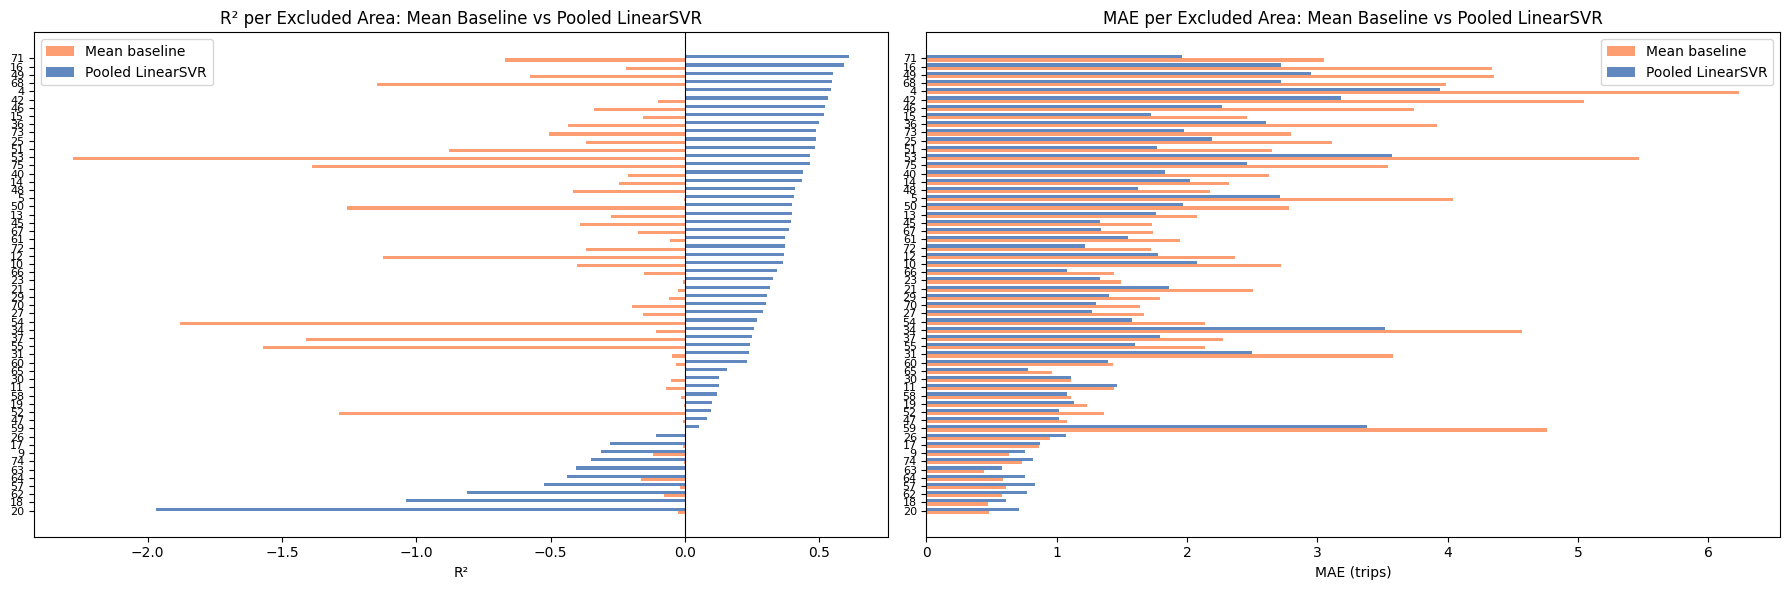

In [179]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: R² comparison per area
comp_sorted = comp.sort_values('r2_pooled')
x = np.arange(len(comp_sorted))
w = 0.38

axes[0].barh(x - w/2, comp_sorted['r2_mean'],   w, label='Mean baseline',     color='#fc8d59', alpha=0.85)
axes[0].barh(x + w/2, comp_sorted['r2_pooled'], w, label='Pooled LinearSVR',  color='#4575b4', alpha=0.85)
axes[0].set_yticks(x)
axes[0].set_yticklabels(comp_sorted['community_area'].astype(str), fontsize=8)
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].set_xlabel('R²')
axes[0].set_title('R² per Excluded Area: Mean Baseline vs Pooled LinearSVR')
axes[0].legend()

# Right: MAE comparison
axes[1].barh(x - w/2, comp_sorted['mae_mean'],   w, label='Mean baseline',    color='#fc8d59', alpha=0.85)
axes[1].barh(x + w/2, comp_sorted['mae_pooled'], w, label='Pooled LinearSVR', color='#4575b4', alpha=0.85)
axes[1].set_yticks(x)
axes[1].set_yticklabels(comp_sorted['community_area'].astype(str), fontsize=8)
axes[1].set_xlabel('MAE (trips)')
axes[1].set_title('MAE per Excluded Area: Mean Baseline vs Pooled LinearSVR')
axes[1].legend()

plt.tight_layout()
plt.show()
